In [2]:
import sys, os
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

from data_processing import MelDataManager

In [4]:
data_folder = "../../data/genres_original"
classes = ['blues', 'classical', 'country', 'disco', 'hiphop','jazz', 'metal', 'pop', 'reggae', 'rock']

mgr = MelDataManager(
    data_folder=data_folder,
    classes=classes,
    cache_path="../../data/processed/melspec_cache.npz",
    target_shape=(150, 150),
    chunk_duration=4,
    overlap_duration=2,
)

data, labels = mgr.load_or_build_cache()

Loaded cached data from ../../data/processed/melspec_cache.npz


In [5]:
labels = mgr.one_hot()
print(f"Labels shape: {labels.shape}")

Labels shape: (14975, 10)


In [6]:
X_train, X_test, Y_train, Y_test = mgr.split(test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (11980, 150, 150, 1), Test shape: (2995, 150, 150, 1)


In [7]:
# Konwersja na RGB (MobileNetV2 wymaga 3 kanałów)
import numpy as np
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)
print(f"Przed RGB: {X_train.shape}")
print(f"Po RGB: {X_train_rgb.shape}")

Przed RGB: (11980, 150, 150, 1)
Po RGB: (11980, 150, 150, 3)


In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

base_model = MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
output = layers.Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\piotr\AppData\Local\Temp\ipykernel_26684\1998531450.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
history = model.fit(
    X_train_rgb, Y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
 88/300 ━━━━━━━━━━━━━━━━━━━━ 2:32 717ms/step - accuracy: 0.2714 - loss: 2.3386

KeyboardInterrupt: 

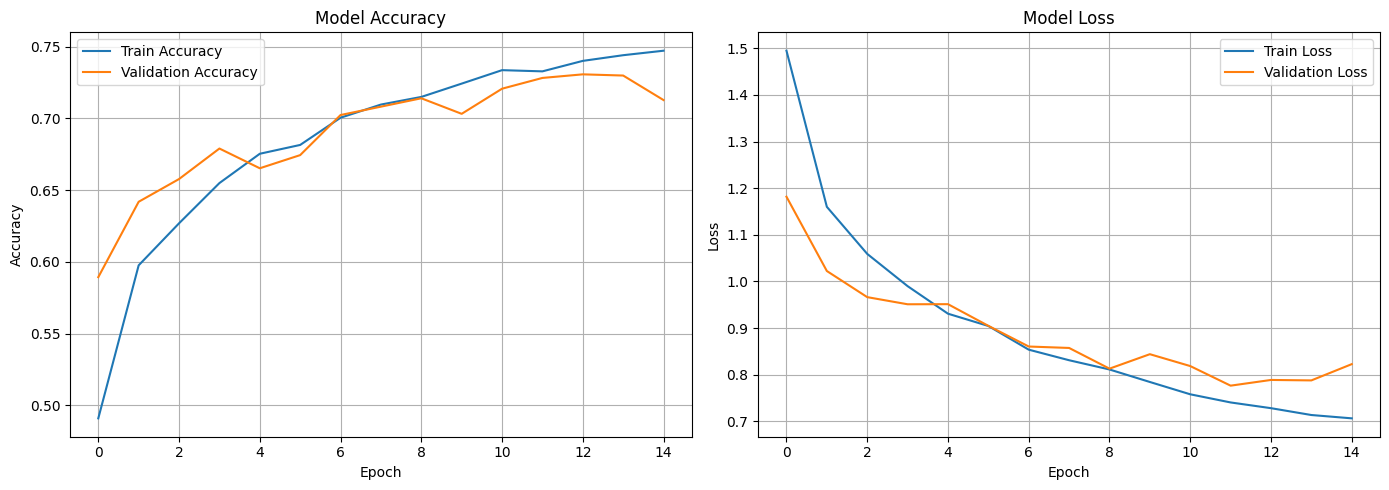

In [ ]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Ewaluacja na zbiorze testowym
test_loss, test_acc = model.evaluate(X_test_rgb, Y_test, verbose=1)
print(f"\nDokładność na zbiorze testowym: {test_acc:.2%}")
print(f"Strata na zbiorze testowym: {test_loss:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.7346 - loss: 0.7927
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.7346 - loss: 0.7927

Dokładność na zbiorze testowym: 73.46%
Strata na zbiorze testowym: 0.7927

Dokładność na zbiorze testowym: 73.46%
Strata na zbiorze testowym: 0.7927


94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step


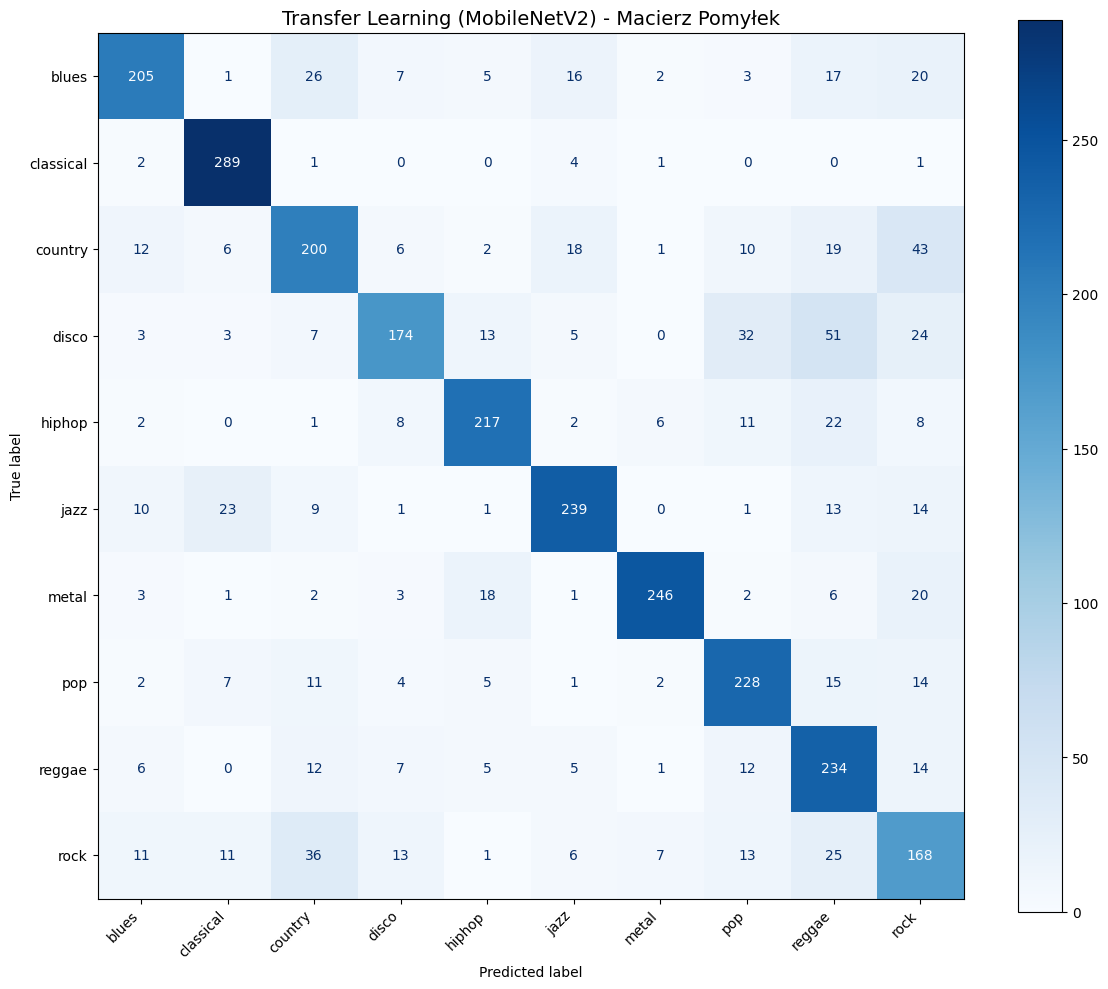


Raport klasyfikacji:
              precision    recall  f1-score   support

       blues       0.80      0.68      0.73       302
   classical       0.85      0.97      0.90       298
     country       0.66      0.63      0.64       317
       disco       0.78      0.56      0.65       312
      hiphop       0.81      0.78      0.80       277
        jazz       0.80      0.77      0.79       311
       metal       0.92      0.81      0.87       302
         pop       0.73      0.79      0.76       289
      reggae       0.58      0.79      0.67       296
        rock       0.52      0.58      0.54       291

    accuracy                           0.73      2995
   macro avg       0.75      0.74      0.74      2995
weighted avg       0.75      0.73      0.74      2995



In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

Y_pred_proba = model.predict(X_test_rgb)
Y_pred_classes = np.argmax(Y_pred_proba, axis=1)
Y_true_classes = np.argmax(Y_test, axis=1)

cm = confusion_matrix(Y_true_classes, Y_pred_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(12, 10))
cm_display.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Transfer Learning (MobileNetV2) - Macierz Pomyłek', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nRaport klasyfikacji:")
print(classification_report(Y_true_classes, Y_pred_classes, target_names=classes))

In [ ]:
model.save('../models/transfer_learning_model.keras')
print("Model zapisany jako: ../models/transfer_learning_model.keras")

Model zapisany jako: ../models/transfer_learning_model.keras


In [ ]:
# # Fine-tuning (opcjonalnie - odmrożenie części warstw bazowych)
# print("Rozpoczynam fine-tuning...")

# # Odmroź ostatnie 30 warstw
# base_model.trainable = True
# for layer in base_model.layers[:-30]:
#     layer.trainable = False

# # Rekompiluj z mniejszą learning rate
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# # Dotrenuj
# history_fine = model.fit(
#     X_train_rgb, Y_train,
#     validation_split=0.2,
#     epochs=10,
#     batch_size=32,
#     verbose=1
# )

In [ ]:
# # Ewaluacja po fine-tuningu
# test_loss_fine, test_acc_fine = model.evaluate(X_test_rgb, Y_test, verbose=1)
# print(f"\nDokładność po fine-tuningu: {test_acc_fine:.2%}")
# print(f"Poprawa: {(test_acc_fine - test_acc)*100:.2f} punktów procentowych")

In [ ]:
# # Zapisz model
# model.save('../models/transfer_learning_model.keras')
# print("Model zapisany jako: ../models/transfer_learning_model.keras")